In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# GDS factrory imports
import gdsfactory as gf
from gdsfactory.typings import Layer


# NOTE: In GDS factory all dimensions are in um.

Frame cell. The active region of the slide available for making TCs

In [2]:
# 15 mm x 15 mm area usable on slide. 

@gf.cell
def die(
    size: gf.typings.Size = (10000.0, 10000.0),
    street_width: float = 100.0,
    street_length: float = 1000.0,
    die_name: str | None = "chip99",
    text_size: float = 100.0,
    text_location: str | gf.typings.Float2 = "SW",
    layer: gf.typings.LayerSpec | None = "FLOORPLAN",
    bbox_layer: gf.typings.LayerSpec | None = "FLOORPLAN",
    text: gf.typings.ComponentSpec = "text",
    draw_corners: bool = False,
) -> gf.Component:
    """Returns die with optional markers marking the boundary of the die.

    Args:
        size: x, y dimensions of the die.
        street_width: Width of the corner marks for die-sawing.
        street_length: Length of the corner marks for die-sawing.
        die_name: Label text. If None, no label is added.
        text_size: Label text size.
        text_location: {'NW', 'N', 'NE', 'SW', 'S', 'SE'} or (x, y) coordinate.
        layer: For street widths. None to not draw the street widths.
        bbox_layer: optional bbox layer drawn bounding box around the die.
        text: function use for generating text. Needs to accept text, size, layer.
        draw_corners: True draws only corners. False draws a square die.
    """
    c = gf.Component()
    sx, sy = size[0] / 2, size[1] / 2

    if layer:
        if not draw_corners:
            street_length = sx
        xpts = np.array(
            [
                sx,
                sx,
                sx - street_width,
                sx - street_width,
                sx - street_length,
                sx - street_length,
            ]
        )
        if not draw_corners:
            street_length = sy
        ypts = np.array(
            [
                sy,
                sy - street_length,
                sy - street_length,
                sy - street_width,
                sy - street_width,
                sy,
            ]
        )
        c.add_polygon(list(zip(xpts, ypts, strict=False)), layer=layer)
        c.add_polygon(list(zip(-xpts, ypts, strict=False)), layer=layer)
        c.add_polygon(list(zip(xpts, -ypts, strict=False)), layer=layer)
        c.add_polygon(list(zip(-xpts, -ypts, strict=False)), layer=layer)

    if bbox_layer:
        c.add_polygon([(sx, sy), (sx, -sy), (-sx, -sy), (-sx, sy)], layer=bbox_layer)

    if die_name:
        text_component = gf.get_component(
            text, text=die_name, size=text_size, layer="TEXT"
        )
        t = c.add_ref(text_component)

        d = street_width + 20
        if isinstance(text_location, str):
            text_location = text_location.upper()
            if text_location == "N":
                t.x, t.ymax = [0, sy - d]
            elif text_location == "NE":
                t.xmax, t.ymax = [sx - d, sy - d]
            elif text_location == "NW":
                t.xmin, t.ymax = [-sx + d, sy - d]
            elif text_location == "S":
                t.x, t.ymin = [0, -sy + d]
            elif text_location == "SE":
                t.xmax, t.ymin = [sx - d, -sy + d]
            elif text_location == "SW":
                t.xmin, t.ymin = [-sx + d, -sy + d]
            else:
                raise ValueError(
                    f"Invalid text_location: {text_location} not in N, NE, NW, S, SE, SW"
                )
        else:
            t.x, t.y = text_location

    return c

Contact Pads (0.5 mm squared)

In [3]:
# 0.5 mm x 0.5 mm contact pad.

@gf.cell
def contact_pad(
    size: gf.typings.Size = (500.0, 500.0),
    layer: gf.typings.LayerSpec = (1, 0),
    port_width: float = 10.0,
    port_orientation: float = 0.0, # 0=Right, 90=Top, 180=Left, 270=Bottom
) -> gf.Component:
    """Returns a square/rectangular contact pad with a connection port.

    Args:
        size: Width (x) and height (y) dimensions of the contact pad.
        layer: GDS layer for the pad metal.
        port_width: Width of the trace connection track port.
        port_orientation: Angle of the port facing direction in degrees.
    """
    c = gf.Component()
    sx, sy = size[0] / 2.0, size[1] / 2.0

    # 1. Draw the main square pad centered at (0, 0)
    c.add_polygon(
        [(-sx, -sy), (sx, -sy), (sx, sy), (-sx, sy)], 
        layer=layer
    )

    # 2. Add an optical/electrical port for track routing
    # We position the port precisely on the edge based on user orientation
    if port_orientation == 0.0:     # Right edge
        port_center = (sx, 0.0)
    elif port_orientation == 90.0:   # Top edge
        port_center = (0.0, sy)
    elif port_orientation == 180.0:  # Left edge
        port_center = (-sx, 0.0)
    elif port_orientation == 270.0:  # Bottom edge
        port_center = (0.0, -sy)
    else:
        # Fallback to center if a custom angle is input
        port_center = (0.0, 0.0)

    c.add_port(
        name="e1",                  # Port identifier name
        center=port_center,         # Exact connection point coordinate
        width=port_width,           # Matches your interconnect wire track width
        orientation=port_orientation, 
        layer=layer,
        port_type="electrical"      # Specifies this is for conductive paths
    )

    return c

Scalable object for the thermocouple overlap (junction)

In [68]:
@gf.cell
def thermocouple_junction(
    w: float = 3.0,                  # Overlap width (square overlap)
    layer_bottom: gf.typings.LayerSpec = (1, 0), # Au Bottom Layer
    layer_top: gf.typings.LayerSpec = (2, 0),    # Ni Top Layer
    text = True,
) -> gf.Component:
    """Returns a scalable chiral thermocouple junction.
    
    The geometry scales dynamically based on the parameter `w`.
    Maintains a perfect vertical overlap contact zone at the center.
    """
    c = gf.Component()

    # 1. Generate parameterized coordinates based on 'w'
    coords_layer1 = [
        (0.0, 0.0),
        (0.0, 2 * w),
        (2 * w, 2 * w),
        (2 * w, w),
        (w, w),
        (w, 0.0),
    ]

    # Mirror horizontally and shift by 3*w to sit the chiral edge perfectly 
    # on the original (2*w, w) -> (w, w) segment.
    coords_layer2 = [(-x + 3 * w, y) for x, y in coords_layer1]

    # 2. Add Polygons
    c.add_polygon(coords_layer1, layer=layer_bottom)
    c.add_polygon(coords_layer2, layer=layer_top)

    # 3. Add Dynamic Labels centered in the non-overlapped vertical legs
    # Left leg center: X = 0.5*w, Y = 1.0*w
    if text:
        c.add_label(text="Au_Bottom_Layer", position=(0.35 * w, 1.0 * w), layer=layer_bottom)
    
        # Right leg center: X = 2.5*w, Y = 1.0*w
        c.add_label(text="Ni_Top_Layer", position=(2.35 * w, 1.0 * w), layer=layer_top)
        
        # Header label centered above the central junction area
        c.add_label(text=f"{int(w)}x{int(w)} Thermocouple", position=(1.5 * w, 2.2 * w), layer=(0, 0))

    # 4. Add Electrical Ports for easy track routing
    c.add_port(
        name="e1_gold",
        center=(0.5 * w, 0.0),
        width=w,
        orientation=270,
        layer=layer_bottom,
        port_type="electrical"
    )
    
    c.add_port(
        name="e2_nickel",
        center=(2.5 * w, 0.0),
        width=w,
        orientation=270,
        layer=layer_top,
        port_type="electrical"
    )

    return c

In [69]:
# generic PDK
gf.gpdk.PDK.activate()

Example Thermocouple junction. gf.cell made above based on it. 

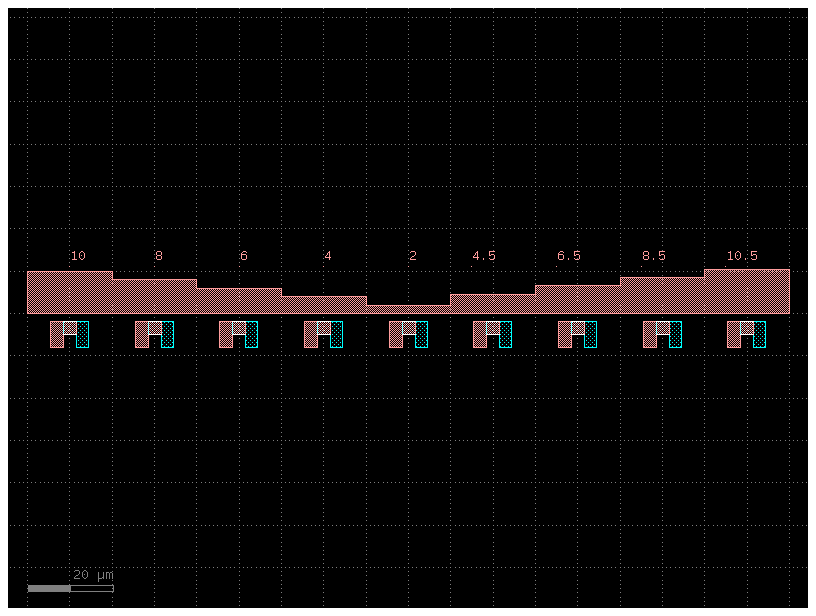

In [79]:
gf.clear_cache()

# blank component
heater = gf.Component("Stepped_Heater")

# 2. Define the original right-angled coordinates (Layer 1)
coords_layer1 = [
    (0.0, 0.0),
    (0.0, 10.0),
    (20.0, 10.0),
    (20.0, 8.0),
    (40.0, 8.0),
    (40.0, 6.0),
    (60.0, 6.0),
    (60.0, 4.0),
    (80.0, 4.0),
    (80.0, 2.0),
    (100.0, 2.0),
    (100.0, 4.50),
    (120.0, 4.50),
    (120.0, 6.50),
    (140.0, 6.50),
    (140.0, 8.50),
    (160.0, 8.50),
    (160.0, 10.50),
    (180.0, 10.50),
    (180, 0),
    (0, 0)
]

# Add poolygons to layers
p1 = heater.add_polygon(coords_layer1, layer=(1, 0))


for i in range(9):
    tc = thermocouple_junction(text=False)
    tc_ref = heater << tc
    tc_ref.center = (10 + 20 *i, -5)
    

# tc1_ref = heater << tc1
# tc1_ref.center = (10,-5)

# tc1_ref = heater << tc1
# tc1_ref.center = (10,-5)

# tc1_ref = heater << tc1
# tc1_ref.center = (10,-5)

# tc1_ref = heater << tc1
# tc1_ref.center = (10,-5)

# tc1_ref = heater << tc1
# tc1_ref.center = (10,-5)

# tc1_ref = heater << tc1
# tc1_ref.center = (10,-5)

# tc1_ref = heater << tc1
# tc1_ref.center = (10,-5)

heater.add_label(text="10", position = (10, 11), layer = (0,0))
heater.add_label(text="8", position = (30, 11), layer = (0,0))
heater.add_label(text="6", position = (50, 11), layer = (0,0))
heater.add_label(text="4", position = (70, 11), layer = (0,0))
heater.add_label(text="2", position = (90, 11), layer = (0,0))
heater.add_label(text="4.5", position = (105, 11), layer = (0,0))
heater.add_label(text="6.5", position = (125, 11), layer = (0,0))
heater.add_label(text="8.5", position = (145, 11), layer = (0,0))
heater.add_label(text="10.5", position = (165, 11), layer = (0,0))


heater.write_gds("sample_heater.gds")
heater.plot()

Putting these components together in a single GDS

958 389


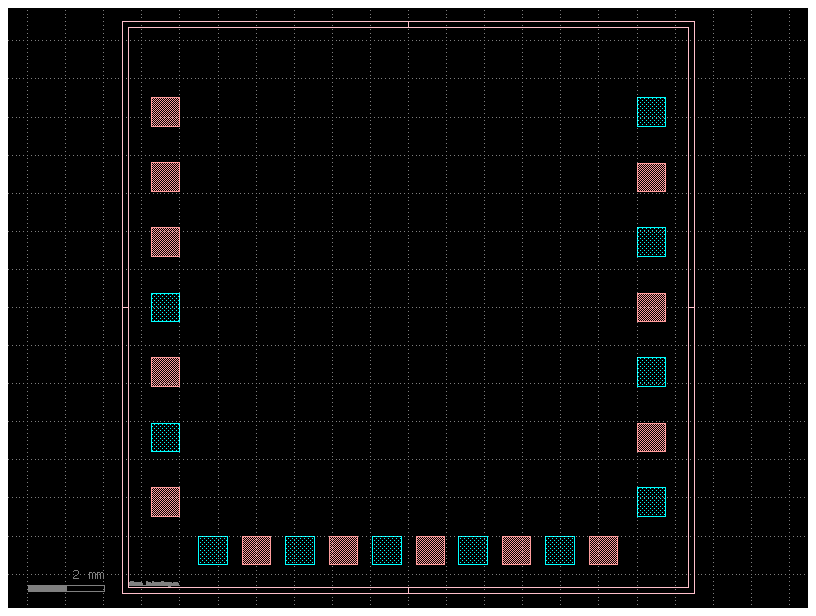

In [37]:
gf.clear_cache()

# Components to add to main component
Frame = die(
    size=(15000, 15000),      # 15 mm x 15 mm
    street_width=150,         
    die_name="15mm_ActiveRegion", 
    text_location="SW",       # text bottom left
    layer="FLOORPLAN",
    bbox_layer="FLOORPLAN",
    draw_corners=False        
)

# Creating Contact pads assigned to each layer with ports oriented per PCB design. 
# need to add power and ground to bottom layer and then every second one to Au/Ni layers. 
# layer setting is mod 2 so every second one is on a different layer.
port_dict = {}
contactpad_size = 750
for i in range(1,25):
    if i <= 2:
        port_dict[f"cp{i}"] = contact_pad(size=(contactpad_size, contactpad_size), layer=(1, 0), port_width=100.0, port_orientation=0.0)
    elif i < 8:
        port_dict[f"cp{i}"] = contact_pad(size=(contactpad_size, contactpad_size), layer=((i+1) % 2 + 1, 0), port_width=100.0, port_orientation=0.0)
    elif i < 18:
        port_dict[f"cp{i}"] = contact_pad(size=(contactpad_size, contactpad_size), layer=((i+1) % 2 + 1, 0), port_width=100.0, port_orientation=90.0)
    else:
        port_dict[f"cp{i}"] = contact_pad(size=(contactpad_size, contactpad_size), layer=((i+1) % 2 + 1, 0), port_width=100.0, port_orientation=180.0)
        
# Thermocouple Junctions with ports. 

# Main Component. All components above will be added here. 
TC = gf.Component("Example combination of sample TC and Frame")

# Add frame and Thermocouple to the TC cell
addFrame = TC.add_ref(Frame)
# addTC = TC.add_ref(sampleTC)

side_clearance =  round((11000 - 7 * contactpad_size) / 6)
bottom_clearance = round((11000 - 10 * contactpad_size) / 9)
bottom_x_offset = -5500
side_y_offset = 5500

print(side_clearance, bottom_clearance)

add_port_dict = {}
for i in range(1,25):
    add_port_dict[f"add_cp{i}"] = TC << port_dict[f"cp{i}"]

    # Here, I need to spread the contact pads evenly along each side. (1,7)L, (8,17)B, (18,24)R
    if i < 8:
        add_port_dict[f"add_cp{i}"].center = (-7500 + 1.5 * contactpad_size, side_y_offset - (side_clearance + contactpad_size) * (i-1) - contactpad_size/2)

    elif i < 18: 
        add_port_dict[f"add_cp{i}"].center = (bottom_x_offset + (bottom_clearance + contactpad_size) * (i-8) + contactpad_size/2, -7500 + 1.5 * contactpad_size)

    else:
        add_port_dict[f"add_cp{i}"].center = (7500 - 1.5 * contactpad_size, side_y_offset - (side_clearance + contactpad_size) * (i-18)  -contactpad_size/2)

TC.plot()